In [1]:
import pandas as pd
import seaborn as sns

from scipy.stats import kruskal
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator

plt.rcParams['font.family'] = 'Arial'

import warnings
warnings.filterwarnings("ignore")

In [2]:
cd C:\Users\tr432\Downloads

C:\Users\tr432\Downloads


In [3]:
## qzv 파일 Qiime2View에 넣고 'Download raw data as TSV' 로 다운받은 후 파일명만 바꿔서 사용
w0_faithpd = pd.read_csv('filter_GutLungAxis_Week0/faith.tsv', sep='\t', skiprows=[1], usecols=['id', 'Group', 'faith_pd'])
w0_observed = pd.read_csv('filter_GutLungAxis_Week0/observed.tsv', sep='\t', skiprows=[1], usecols=['id', 'Group', 'observed_features'])
w0_shannon = pd.read_csv('filter_GutLungAxis_Week0/shannon.tsv', sep='\t', skiprows=[1], usecols=['id', 'Group', 'shannon_entropy'])
w0_ace = pd.read_csv('filter_GutLungAxis_Week0/ace.tsv', sep='\t', skiprows=[1], usecols=['id', 'Group', 'ace'])
w0_chao1 = pd.read_csv('filter_GutLungAxis_Week0/chao1.tsv', sep='\t', skiprows=[1], usecols=['id', 'Group', 'chao1'])
w0_simpson = pd.read_csv('filter_GutLungAxis_Week0/simpson.tsv', sep='\t', skiprows=[1])
val = [c for c in w0_simpson.columns if c not in ['id','Group']][-1]
w0_simpson = w0_simpson[['id','Group', val]].rename(columns={val: 'simpson'})  ## 파일마다 simpson 부분 열이름이 달라서 불러오는 과정이 좀 복잡함
w0_pielou = pd.read_csv('filter_GutLungAxis_Week0/pielou.tsv', sep='\t', skiprows=[1], usecols=['id', 'Group', 'pielou_evenness'])

w1_faithpd = pd.read_csv('filter_GutLungAxis_Week1/faith.tsv', sep='\t', skiprows=[1], usecols=['id', 'Group', 'faith_pd'])
w1_observed = pd.read_csv('filter_GutLungAxis_Week1/observed.tsv', sep='\t', skiprows=[1], usecols=['id', 'Group', 'observed_features'])
w1_shannon = pd.read_csv('filter_GutLungAxis_Week1/shannon.tsv', sep='\t', skiprows=[1], usecols=['id', 'Group', 'shannon_entropy'])
w1_ace = pd.read_csv('filter_GutLungAxis_Week1/ace.tsv', sep='\t', skiprows=[1], usecols=['id', 'Group', 'ace'])
w1_chao1 = pd.read_csv('filter_GutLungAxis_Week1/chao1.tsv', sep='\t', skiprows=[1], usecols=['id', 'Group', 'chao1'])
w1_simpson = pd.read_csv('filter_GutLungAxis_Week1/simpson.tsv', sep='\t', skiprows=[1])
val = [c for c in w1_simpson.columns if c not in ['id','Group']][-1]
w1_simpson = w1_simpson[['id','Group', val]].rename(columns={val: 'simpson'})  ## 파일마다 simpson 부분 열이름이 달라서 불러오는 과정이 좀 복잡함
w1_pielou = pd.read_csv('filter_GutLungAxis_Week1/pielou.tsv', sep='\t', skiprows=[1], usecols=['id', 'Group', 'pielou_evenness'])

w2_faithpd = pd.read_csv('filter_GutLungAxis_Week2/faith.tsv', sep='\t', skiprows=[1], usecols=['id', 'Group', 'faith_pd'])
w2_observed = pd.read_csv('filter_GutLungAxis_Week2/observed.tsv', sep='\t', skiprows=[1], usecols=['id', 'Group', 'observed_features'])
w2_shannon = pd.read_csv('filter_GutLungAxis_Week2/shannon.tsv', sep='\t', skiprows=[1], usecols=['id', 'Group', 'shannon_entropy'])
w2_ace = pd.read_csv('filter_GutLungAxis_Week2/ace.tsv', sep='\t', skiprows=[1], usecols=['id', 'Group', 'ace'])
w2_chao1 = pd.read_csv('filter_GutLungAxis_Week2/chao1.tsv', sep='\t', skiprows=[1], usecols=['id', 'Group', 'chao1'])
w2_simpson = pd.read_csv('filter_GutLungAxis_Week2/simpson.tsv', sep='\t', skiprows=[1])
val = [c for c in w2_simpson.columns if c not in ['id','Group']][-1]
w2_simpson = w2_simpson[['id','Group', val]].rename(columns={val: 'simpson'})  ## 파일마다 simpson 부분 열이름이 달라서 불러오는 과정이 좀 복잡함
w2_pielou = pd.read_csv('filter_GutLungAxis_Week2/pielou.tsv', sep='\t', skiprows=[1], usecols=['id', 'Group', 'pielou_evenness'])

print(w0_simpson.head(3))
print(w1_simpson.head(3))
print(w2_simpson.head(3))
print(w2_shannon.head(3))

       id    Group   simpson
0  C03-0w  Control  0.938007
1  C04-0w  Control  0.966586
2  C05-0w  Control  0.958823
       id    Group   simpson
0  C01-1w  Control  0.982683
1  C02-1w  Control  0.980464
2  C03-1w  Control  0.946539
       id    Group   simpson
0  C01-2w  Control  0.976806
1  C02-2w  Control  0.985822
2  C03-2w  Control  0.984305
       id    Group  shannon_entropy
0  C01-2w  Control         6.853155
1  C02-2w  Control         7.670010
2  C03-2w  Control         6.993449


In [4]:
## Group 종류 확인
print(w0_faithpd.Group.unique())
print(w0_observed.Group.unique())
print(w0_shannon.Group.unique())
print(w0_ace.Group.unique())
print(w0_chao1.Group.unique())
print(w0_simpson.Group.unique())
print(w0_pielou.Group.unique())

print(w1_faithpd.Group.unique())
print(w1_observed.Group.unique())
print(w1_shannon.Group.unique())
print(w1_ace.Group.unique())
print(w1_chao1.Group.unique())
print(w1_simpson.Group.unique())
print(w1_pielou.Group.unique())

print(w2_faithpd.Group.unique())
print(w2_observed.Group.unique())
print(w2_shannon.Group.unique())
print(w2_ace.Group.unique())
print(w2_chao1.Group.unique())
print(w2_simpson.Group.unique())
print(w2_pielou.Group.unique())

['Control' 'VNAM']
['Control' 'VNAM']
['Control' 'VNAM']
['Control' 'VNAM']
['Control' 'VNAM']
['Control' 'VNAM']
['Control' 'VNAM']
['Control' 'VNAM']
['Control' 'VNAM']
['Control' 'VNAM']
['Control' 'VNAM']
['Control' 'VNAM']
['Control' 'VNAM']
['Control' 'VNAM']
['Control' 'VNAM']
['Control' 'VNAM']
['Control' 'VNAM']
['Control' 'VNAM']
['Control' 'VNAM']
['Control' 'VNAM']
['Control' 'VNAM']


In [5]:
# 1) Week 붙여서 합치기
alpha_all = pd.concat([
    w0_faithpd.assign(Week="Week0"),
    w1_faithpd.assign(Week="Week1"),
    w2_faithpd.assign(Week="Week2"),
], ignore_index=True)

# 2) 6개 그룹 라벨 만들기: w0_con, w0_vnam, ...
alpha_all["Group6"] = alpha_all["Week"] + "_" + alpha_all["Group"]#.str.lower()

print(sorted(alpha_all["Group6"].unique()))

['Week0_Control', 'Week0_VNAM', 'Week1_Control', 'Week1_VNAM', 'Week2_Control', 'Week2_VNAM']


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Week0_Control vs. Week0_VNAM: Kruskal-Wallis independent samples (pairwise between groups), P_val:1.000e+00 Stat=0.000e+00
Week1_Control vs. Week1_VNAM: Kruskal-Wallis independent samples (pairwise between groups), P_val:1.075e-04 Stat=1.500e+01
Week2_Control vs. Week2_VNAM: Kruskal-Wallis independent samples (pairwise between groups), P_val:1.138e-03 Stat=1.059e+01


[Text(0, 0, 'Control'),
 Text(1, 0, 'VNAM'),
 Text(2, 0, 'Control'),
 Text(3, 0, 'VNAM'),
 Text(4, 0, 'Control'),
 Text(5, 0, 'VNAM')]

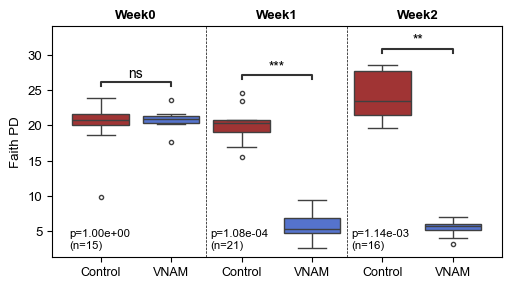

In [6]:
## Faith PD

# 1) Week 붙여서 합치기
alpha_all = pd.concat([
    w0_faithpd.assign(Week="Week0"),
    w1_faithpd.assign(Week="Week1"),
    w2_faithpd.assign(Week="Week2"),
], ignore_index=True)

# 2) 6개 그룹 라벨 만들기: w0_con, w0_vnam, ...
alpha_all["Group6"] = alpha_all["Week"] + "_" + alpha_all["Group"]#.str.lower()

order = ["Week0_Control", "Week0_VNAM", "Week1_Control", "Week1_VNAM", "Week2_Control", "Week2_VNAM"]
# (원하면 con으로 줄이기)
#alpha_all["Group6"] = alpha_all["Group6"].replace({"w0_control":"w0_con","w1_control":"w1_con","w2_control":"w2_con"})
#order = ["w0_con","w0_vnam","w1_con","w1_vnam","w2_con","w2_vnam"]

# 3) plot
palette = ["firebrick", "royalblue"] * 3

fig, ax = plt.subplots(figsize=(5.8, 3))
sns.boxplot(data=alpha_all, x="Group6", y="faith_pd",
            order=order, palette=palette, fliersize=3, ax=ax)

# 4) 통계(각 Week에서 Control vs VNAM 3개 비교)
pairs = [("Week0_Control","Week0_VNAM"), ("Week1_Control","Week1_VNAM"), ("Week2_Control","Week2_VNAM")]
annot = Annotator(ax, pairs, data=alpha_all, x="Group6", y="faith_pd", order=order)
annot.configure(test="Kruskal", text_format="star", loc="inside")
annot.apply_test()
annot.annotate()

weeks = ["Week0", "Week1", "Week2"]
wk_info = {}  # {"Week0": (n_con, n_vnam, p), ...}

for wk in weeks:
    sub = alpha_all[alpha_all["Week"] == wk]
    con = sub.loc[sub["Group"] == "Control", "faith_pd"].dropna()
    vnam = sub.loc[sub["Group"] == "VNAM", "faith_pd"].dropna()
    stat, p = kruskal(con, vnam)
    wk_info[wk] = (len(con), len(vnam), p)

# 5) 2개 단위로 구분선(Seaborn 범주 위치는 0~5라서 경계는 1.5, 3.5)
ax.axvline(1.5, ymin=0, ymax=1, ls="--", lw=0.5, c="black")
ax.axvline(3.5, ymin=0, ymax=1, ls="--", lw=0.5, c="black")
# 사용자가 쓰던 절대 y범위로 자르고 싶으면:
# ax.vlines([1.5, 3.5], ymin=-5, ymax=35, linestyles="--", linewidth=0.5, colors="black")

trans = ax.get_xaxis_transform()  # x는 data좌표(0~5), y는 axes비율(0~1)

# 각 구역 center(x)와 left(x)
centers = {"Week0": 0.5, "Week1": 2.5, "Week2": 4.5}
lefts   = {"Week0": -0.45, "Week1": 1.55, "Week2": 3.55}

for wk in weeks:
    n_con, n_vnam, p = wk_info[wk]

    # 구역 위 제목
    ax.text(
        centers[wk], 1.02, wk,
        transform=trans, ha="center", va="bottom",
        fontsize=9.5, fontweight="bold", clip_on=False
    )

    # 구역 왼쪽 아래 n/p (원하면 n_con/n_vnam 형태로)
    ax.text(
        lefts[wk], 0.03,
        f"p={p:.2e}\n(n={n_con+n_vnam})",
        transform=trans, ha="left", va="bottom",
        fontsize=8.2
    )

ax.set_ylabel("Faith PD", fontsize=9.5)
ax.set_xlabel("")
#ax.tick_params(axis="x", labelsize=9, rotation=45)
ax.tick_params(axis="y", labelsize=9.5)

new_labels = ["Control", "VNAM"] * 3
ax.set_xticklabels(new_labels, fontsize=9, rotation=0)

#ax.set_ylim(-100, )

#plt.savefig("faithpd_weeks_merged.tiff", dpi=300, bbox_inches="tight")

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Week0_Control vs. Week0_VNAM: Kruskal-Wallis independent samples (pairwise between groups), P_val:3.458e-01 Stat=8.889e-01
Week1_Control vs. Week1_VNAM: Kruskal-Wallis independent samples (pairwise between groups), P_val:1.075e-04 Stat=1.500e+01
Week2_Control vs. Week2_VNAM: Kruskal-Wallis independent samples (pairwise between groups), P_val:1.129e-03 Stat=1.060e+01


(-100.0, 875.9145667724872)

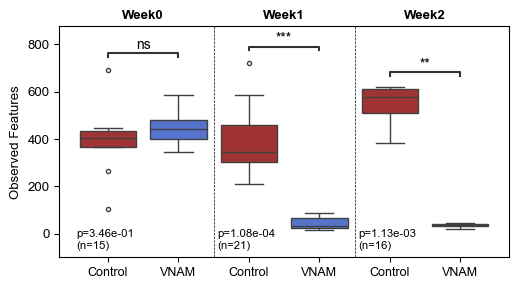

In [7]:
## Observed Features

# 1) Week 붙여서 합치기
alpha_all = pd.concat([
    w0_observed.assign(Week="Week0"),
    w1_observed.assign(Week="Week1"),
    w2_observed.assign(Week="Week2"),
], ignore_index=True)

# 2) 6개 그룹 라벨 만들기: w0_con, w0_vnam, ...
alpha_all["Group6"] = alpha_all["Week"] + "_" + alpha_all["Group"]#.str.lower()

order = ["Week0_Control", "Week0_VNAM", "Week1_Control", "Week1_VNAM", "Week2_Control", "Week2_VNAM"]
# (원하면 con으로 줄이기)
#alpha_all["Group6"] = alpha_all["Group6"].replace({"w0_control":"w0_con","w1_control":"w1_con","w2_control":"w2_con"})
#order = ["w0_con","w0_vnam","w1_con","w1_vnam","w2_con","w2_vnam"]

# 3) plot
palette = ["firebrick", "royalblue"] * 3

fig, ax = plt.subplots(figsize=(5.8, 3))
sns.boxplot(data=alpha_all, x="Group6", y="observed_features",
            order=order, palette=palette, fliersize=3, ax=ax)

# 4) 통계(각 Week에서 Control vs VNAM 3개 비교)
pairs = [("Week0_Control","Week0_VNAM"), ("Week1_Control","Week1_VNAM"), ("Week2_Control","Week2_VNAM")]
annot = Annotator(ax, pairs, data=alpha_all, x="Group6", y="observed_features", order=order)
annot.configure(test="Kruskal", text_format="star", loc="inside")
annot.apply_test()
annot.annotate()

weeks = ["Week0", "Week1", "Week2"]
wk_info = {}  # {"Week0": (n_con, n_vnam, p), ...}

for wk in weeks:
    sub = alpha_all[alpha_all["Week"] == wk]
    con = sub.loc[sub["Group"] == "Control", "observed_features"].dropna()
    vnam = sub.loc[sub["Group"] == "VNAM", "observed_features"].dropna()
    stat, p = kruskal(con, vnam)
    wk_info[wk] = (len(con), len(vnam), p)

# 5) 2개 단위로 구분선(Seaborn 범주 위치는 0~5라서 경계는 1.5, 3.5)
ax.axvline(1.5, ymin=0, ymax=1, ls="--", lw=0.5, c="black")
ax.axvline(3.5, ymin=0, ymax=1, ls="--", lw=0.5, c="black")
# 사용자가 쓰던 절대 y범위로 자르고 싶으면:
# ax.vlines([1.5, 3.5], ymin=-5, ymax=35, linestyles="--", linewidth=0.5, colors="black")

trans = ax.get_xaxis_transform()  # x는 data좌표(0~5), y는 axes비율(0~1)

# 각 구역 center(x)와 left(x)
centers = {"Week0": 0.5, "Week1": 2.5, "Week2": 4.5}
lefts   = {"Week0": -0.45, "Week1": 1.55, "Week2": 3.55}

for wk in weeks:
    n_con, n_vnam, p = wk_info[wk]

    # 구역 위 제목
    ax.text(
        centers[wk], 1.02, wk,
        transform=trans, ha="center", va="bottom",
        fontsize=9.5, fontweight="bold", clip_on=False
    )

    # 구역 왼쪽 아래 n/p (원하면 n_con/n_vnam 형태로)
    ax.text(
        lefts[wk], 0.03,
        f"p={p:.2e}\n(n={n_con+n_vnam})",
        transform=trans, ha="left", va="bottom",
        fontsize=8.2
    )

ax.set_ylabel("Observed Features", fontsize=9.5)
ax.set_xlabel("")
#ax.tick_params(axis="x", labelsize=9, rotation=45)
ax.tick_params(axis="y", labelsize=9.5)

new_labels = ["Control", "VNAM"] * 3
ax.set_xticklabels(new_labels, fontsize=9, rotation=0)

ax.set_ylim(-100, )

#plt.savefig("observed_weeks_merged.tiff", dpi=300, bbox_inches="tight")

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Week0_Control vs. Week0_VNAM: Kruskal-Wallis independent samples (pairwise between groups), P_val:9.896e-02 Stat=2.722e+00
Week1_Control vs. Week1_VNAM: Kruskal-Wallis independent samples (pairwise between groups), P_val:1.075e-04 Stat=1.500e+01
Week2_Control vs. Week2_VNAM: Kruskal-Wallis independent samples (pairwise between groups), P_val:1.138e-03 Stat=1.059e+01


[Text(0, 0, 'Control'),
 Text(1, 0, 'VNAM'),
 Text(2, 0, 'Control'),
 Text(3, 0, 'VNAM'),
 Text(4, 0, 'Control'),
 Text(5, 0, 'VNAM')]

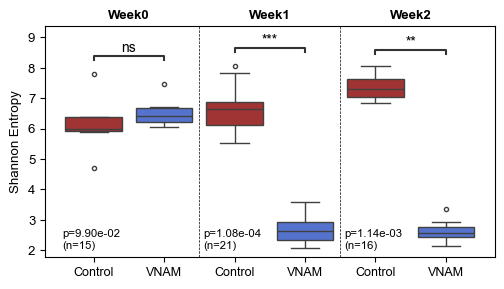

In [8]:
## Shannon Entropy

# 1) Week 붙여서 합치기
alpha_all = pd.concat([
    w0_shannon.assign(Week="Week0"),
    w1_shannon.assign(Week="Week1"),
    w2_shannon.assign(Week="Week2"),
], ignore_index=True)

# 2) 6개 그룹 라벨 만들기: w0_con, w0_vnam, ...
alpha_all["Group6"] = alpha_all["Week"] + "_" + alpha_all["Group"]#.str.lower()

order = ["Week0_Control", "Week0_VNAM", "Week1_Control", "Week1_VNAM", "Week2_Control", "Week2_VNAM"]
# (원하면 con으로 줄이기)
#alpha_all["Group6"] = alpha_all["Group6"].replace({"w0_control":"w0_con","w1_control":"w1_con","w2_control":"w2_con"})
#order = ["w0_con","w0_vnam","w1_con","w1_vnam","w2_con","w2_vnam"]

# 3) plot
palette = ["firebrick", "royalblue"] * 3

fig, ax = plt.subplots(figsize=(5.8, 3))
sns.boxplot(data=alpha_all, x="Group6", y="shannon_entropy",
            order=order, palette=palette, fliersize=3, ax=ax)

# 4) 통계(각 Week에서 Control vs VNAM 3개 비교)
pairs = [("Week0_Control","Week0_VNAM"), ("Week1_Control","Week1_VNAM"), ("Week2_Control","Week2_VNAM")]
annot = Annotator(ax, pairs, data=alpha_all, x="Group6", y="shannon_entropy", order=order)
annot.configure(test="Kruskal", text_format="star", loc="inside")
annot.apply_test()
annot.annotate()

weeks = ["Week0", "Week1", "Week2"]
wk_info = {}  # {"Week0": (n_con, n_vnam, p), ...}

for wk in weeks:
    sub = alpha_all[alpha_all["Week"] == wk]
    con = sub.loc[sub["Group"] == "Control", "shannon_entropy"].dropna()
    vnam = sub.loc[sub["Group"] == "VNAM", "shannon_entropy"].dropna()
    stat, p = kruskal(con, vnam)
    wk_info[wk] = (len(con), len(vnam), p)

# 5) 2개 단위로 구분선(Seaborn 범주 위치는 0~5라서 경계는 1.5, 3.5)
ax.axvline(1.5, ymin=0, ymax=1, ls="--", lw=0.5, c="black")
ax.axvline(3.5, ymin=0, ymax=1, ls="--", lw=0.5, c="black")
# 사용자가 쓰던 절대 y범위로 자르고 싶으면:
# ax.vlines([1.5, 3.5], ymin=-5, ymax=35, linestyles="--", linewidth=0.5, colors="black")

trans = ax.get_xaxis_transform()  # x는 data좌표(0~5), y는 axes비율(0~1)

# 각 구역 center(x)와 left(x)
centers = {"Week0": 0.5, "Week1": 2.5, "Week2": 4.5}
lefts   = {"Week0": -0.45, "Week1": 1.55, "Week2": 3.55}

for wk in weeks:
    n_con, n_vnam, p = wk_info[wk]

    # 구역 위 제목
    ax.text(
        centers[wk], 1.02, wk,
        transform=trans, ha="center", va="bottom",
        fontsize=9.5, fontweight="bold", clip_on=False
    )

    # 구역 왼쪽 아래 n/p (원하면 n_con/n_vnam 형태로)
    ax.text(
        lefts[wk], 0.03,
        f"p={p:.2e}\n(n={n_con+n_vnam})",
        transform=trans, ha="left", va="bottom",
        fontsize=8.2
    )

ax.set_ylabel("Shannon Entropy", fontsize=9.5)
ax.set_xlabel("")
#ax.tick_params(axis="x", labelsize=9, rotation=45)
ax.tick_params(axis="y", labelsize=9.5)

new_labels = ["Control", "VNAM"] * 3
ax.set_xticklabels(new_labels, fontsize=9, rotation=0)

#ax.set_ylim(-100, )

#plt.savefig("shannon_weeks_merged.tiff", dpi=300, bbox_inches="tight")

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Week0_Control vs. Week0_VNAM: Kruskal-Wallis independent samples (pairwise between groups), P_val:4.094e-01 Stat=6.806e-01
Week1_Control vs. Week1_VNAM: Kruskal-Wallis independent samples (pairwise between groups), P_val:1.075e-04 Stat=1.500e+01
Week2_Control vs. Week2_VNAM: Kruskal-Wallis independent samples (pairwise between groups), P_val:1.138e-03 Stat=1.059e+01


(-100.0, 906.4157942857146)

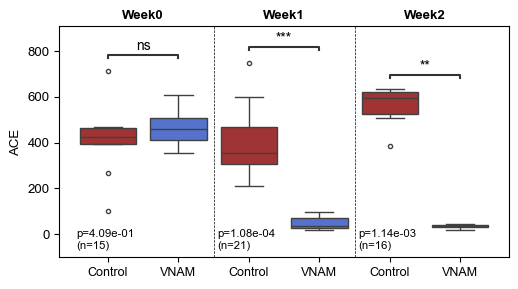

In [9]:
## Ace

# 1) Week 붙여서 합치기
alpha_all = pd.concat([
    w0_ace.assign(Week="Week0"),
    w1_ace.assign(Week="Week1"),
    w2_ace.assign(Week="Week2"),
], ignore_index=True)

# 2) 6개 그룹 라벨 만들기: w0_con, w0_vnam, ...
alpha_all["Group6"] = alpha_all["Week"] + "_" + alpha_all["Group"]#.str.lower()

order = ["Week0_Control", "Week0_VNAM", "Week1_Control", "Week1_VNAM", "Week2_Control", "Week2_VNAM"]
# (원하면 con으로 줄이기)
#alpha_all["Group6"] = alpha_all["Group6"].replace({"w0_control":"w0_con","w1_control":"w1_con","w2_control":"w2_con"})
#order = ["w0_con","w0_vnam","w1_con","w1_vnam","w2_con","w2_vnam"]

# 3) plot
palette = ["firebrick", "royalblue"] * 3

fig, ax = plt.subplots(figsize=(5.8, 3))
sns.boxplot(data=alpha_all, x="Group6", y="ace",
            order=order, palette=palette, fliersize=3, ax=ax)

# 4) 통계(각 Week에서 Control vs VNAM 3개 비교)
pairs = [("Week0_Control","Week0_VNAM"), ("Week1_Control","Week1_VNAM"), ("Week2_Control","Week2_VNAM")]
annot = Annotator(ax, pairs, data=alpha_all, x="Group6", y="ace", order=order)
annot.configure(test="Kruskal", text_format="star", loc="inside")
annot.apply_test()
annot.annotate()

weeks = ["Week0", "Week1", "Week2"]
wk_info = {}  # {"Week0": (n_con, n_vnam, p), ...}

for wk in weeks:
    sub = alpha_all[alpha_all["Week"] == wk]
    con = sub.loc[sub["Group"] == "Control", "ace"].dropna()
    vnam = sub.loc[sub["Group"] == "VNAM", "ace"].dropna()
    stat, p = kruskal(con, vnam)
    wk_info[wk] = (len(con), len(vnam), p)

# 5) 2개 단위로 구분선(Seaborn 범주 위치는 0~5라서 경계는 1.5, 3.5)
ax.axvline(1.5, ymin=0, ymax=1, ls="--", lw=0.5, c="black")
ax.axvline(3.5, ymin=0, ymax=1, ls="--", lw=0.5, c="black")
# 사용자가 쓰던 절대 y범위로 자르고 싶으면:
# ax.vlines([1.5, 3.5], ymin=-5, ymax=35, linestyles="--", linewidth=0.5, colors="black")

trans = ax.get_xaxis_transform()  # x는 data좌표(0~5), y는 axes비율(0~1)

# 각 구역 center(x)와 left(x)
centers = {"Week0": 0.5, "Week1": 2.5, "Week2": 4.5}
lefts   = {"Week0": -0.45, "Week1": 1.55, "Week2": 3.55}

for wk in weeks:
    n_con, n_vnam, p = wk_info[wk]

    # 구역 위 제목
    ax.text(
        centers[wk], 1.02, wk,
        transform=trans, ha="center", va="bottom",
        fontsize=9.5, fontweight="bold", clip_on=False
    )

    # 구역 왼쪽 아래 n/p (원하면 n_con/n_vnam 형태로)
    ax.text(
        lefts[wk], 0.03,
        f"p={p:.2e}\n(n={n_con+n_vnam})",
        transform=trans, ha="left", va="bottom",
        fontsize=8.2
    )

ax.set_ylabel("ACE", fontsize=9.5)
ax.set_xlabel("")
#ax.tick_params(axis="x", labelsize=9, rotation=45)
ax.tick_params(axis="y", labelsize=9.5)

new_labels = ["Control", "VNAM"] * 3
ax.set_xticklabels(new_labels, fontsize=9, rotation=0)

ax.set_ylim(-100, )

#plt.savefig("ace_weeks_merged.tiff", dpi=300, bbox_inches="tight")

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Week0_Control vs. Week0_VNAM: Kruskal-Wallis independent samples (pairwise between groups), P_val:4.094e-01 Stat=6.806e-01
Week1_Control vs. Week1_VNAM: Kruskal-Wallis independent samples (pairwise between groups), P_val:1.075e-04 Stat=1.500e+01
Week2_Control vs. Week2_VNAM: Kruskal-Wallis independent samples (pairwise between groups), P_val:1.138e-03 Stat=1.059e+01


(-100.0, 906.4157942857146)

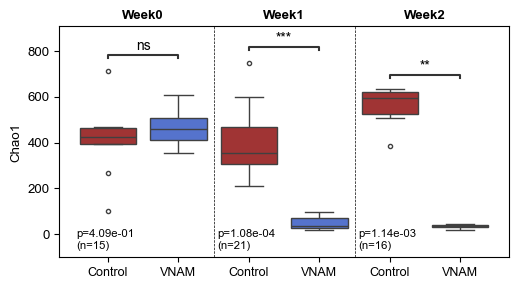

In [10]:
## Chao1

# 1) Week 붙여서 합치기
alpha_all = pd.concat([
    w0_chao1.assign(Week="Week0"),
    w1_chao1.assign(Week="Week1"),
    w2_chao1.assign(Week="Week2"),
], ignore_index=True)

# 2) 6개 그룹 라벨 만들기: w0_con, w0_vnam, ...
alpha_all["Group6"] = alpha_all["Week"] + "_" + alpha_all["Group"]#.str.lower()

order = ["Week0_Control", "Week0_VNAM", "Week1_Control", "Week1_VNAM", "Week2_Control", "Week2_VNAM"]
# (원하면 con으로 줄이기)
#alpha_all["Group6"] = alpha_all["Group6"].replace({"w0_control":"w0_con","w1_control":"w1_con","w2_control":"w2_con"})
#order = ["w0_con","w0_vnam","w1_con","w1_vnam","w2_con","w2_vnam"]

# 3) plot
palette = ["firebrick", "royalblue"] * 3

fig, ax = plt.subplots(figsize=(5.8, 3))
sns.boxplot(data=alpha_all, x="Group6", y="chao1",
            order=order, palette=palette, fliersize=3, ax=ax)

# 4) 통계(각 Week에서 Control vs VNAM 3개 비교)
pairs = [("Week0_Control","Week0_VNAM"), ("Week1_Control","Week1_VNAM"), ("Week2_Control","Week2_VNAM")]
annot = Annotator(ax, pairs, data=alpha_all, x="Group6", y="chao1", order=order)
annot.configure(test="Kruskal", text_format="star", loc="inside")
annot.apply_test()
annot.annotate()

weeks = ["Week0", "Week1", "Week2"]
wk_info = {}  # {"Week0": (n_con, n_vnam, p), ...}

for wk in weeks:
    sub = alpha_all[alpha_all["Week"] == wk]
    con = sub.loc[sub["Group"] == "Control", "chao1"].dropna()
    vnam = sub.loc[sub["Group"] == "VNAM", "chao1"].dropna()
    stat, p = kruskal(con, vnam)
    wk_info[wk] = (len(con), len(vnam), p)

# 5) 2개 단위로 구분선(Seaborn 범주 위치는 0~5라서 경계는 1.5, 3.5)
ax.axvline(1.5, ymin=0, ymax=1, ls="--", lw=0.5, c="black")
ax.axvline(3.5, ymin=0, ymax=1, ls="--", lw=0.5, c="black")
# 사용자가 쓰던 절대 y범위로 자르고 싶으면:
# ax.vlines([1.5, 3.5], ymin=-5, ymax=35, linestyles="--", linewidth=0.5, colors="black")

trans = ax.get_xaxis_transform()  # x는 data좌표(0~5), y는 axes비율(0~1)

# 각 구역 center(x)와 left(x)
centers = {"Week0": 0.5, "Week1": 2.5, "Week2": 4.5}
lefts   = {"Week0": -0.45, "Week1": 1.55, "Week2": 3.55}

for wk in weeks:
    n_con, n_vnam, p = wk_info[wk]

    # 구역 위 제목
    ax.text(
        centers[wk], 1.02, wk,
        transform=trans, ha="center", va="bottom",
        fontsize=9.5, fontweight="bold", clip_on=False
    )

    # 구역 왼쪽 아래 n/p (원하면 n_con/n_vnam 형태로)
    ax.text(
        lefts[wk], 0.03,
        f"p={p:.2e}\n(n={n_con+n_vnam})",
        transform=trans, ha="left", va="bottom",
        fontsize=8.2
    )

ax.set_ylabel("Chao1", fontsize=9.5)
ax.set_xlabel("")
#ax.tick_params(axis="x", labelsize=9, rotation=45)
ax.tick_params(axis="y", labelsize=9.5)

new_labels = ["Control", "VNAM"] * 3
ax.set_xticklabels(new_labels, fontsize=9, rotation=0)

ax.set_ylim(-100, )

#plt.savefig("chao1_weeks_merged.tiff", dpi=300, bbox_inches="tight")

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Week0_Control vs. Week0_VNAM: Kruskal-Wallis independent samples (pairwise between groups), P_val:2.888e-01 Stat=1.125e+00
Week1_Control vs. Week1_VNAM: Kruskal-Wallis independent samples (pairwise between groups), P_val:1.075e-04 Stat=1.500e+01
Week2_Control vs. Week2_VNAM: Kruskal-Wallis independent samples (pairwise between groups), P_val:1.138e-03 Stat=1.059e+01


[Text(0, 0, 'Control'),
 Text(1, 0, 'VNAM'),
 Text(2, 0, 'Control'),
 Text(3, 0, 'VNAM'),
 Text(4, 0, 'Control'),
 Text(5, 0, 'VNAM')]

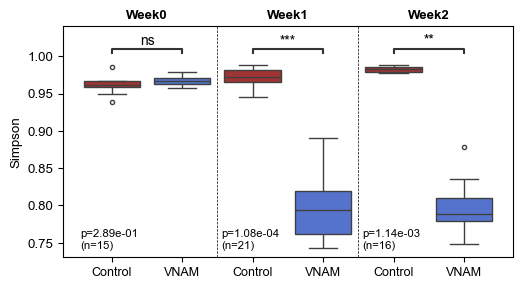

In [11]:
## Simpson

# 1) Week 붙여서 합치기
alpha_all = pd.concat([
    w0_simpson.assign(Week="Week0"),
    w1_simpson.assign(Week="Week1"),
    w2_simpson.assign(Week="Week2"),
], ignore_index=True)

# 2) 6개 그룹 라벨 만들기: w0_con, w0_vnam, ...
alpha_all["Group6"] = alpha_all["Week"] + "_" + alpha_all["Group"]#.str.lower()

order = ["Week0_Control", "Week0_VNAM", "Week1_Control", "Week1_VNAM", "Week2_Control", "Week2_VNAM"]
# (원하면 con으로 줄이기)
#alpha_all["Group6"] = alpha_all["Group6"].replace({"w0_control":"w0_con","w1_control":"w1_con","w2_control":"w2_con"})
#order = ["w0_con","w0_vnam","w1_con","w1_vnam","w2_con","w2_vnam"]

# 3) plot
palette = ["firebrick", "royalblue"] * 3

fig, ax = plt.subplots(figsize=(5.8, 3))
sns.boxplot(data=alpha_all, x="Group6", y="simpson",
            order=order, palette=palette, fliersize=3, ax=ax)

# 4) 통계(각 Week에서 Control vs VNAM 3개 비교)
pairs = [("Week0_Control","Week0_VNAM"), ("Week1_Control","Week1_VNAM"), ("Week2_Control","Week2_VNAM")]
annot = Annotator(ax, pairs, data=alpha_all, x="Group6", y="simpson", order=order)
annot.configure(test="Kruskal", text_format="star", loc="inside")
annot.apply_test()
annot.annotate()

weeks = ["Week0", "Week1", "Week2"]
wk_info = {}  # {"Week0": (n_con, n_vnam, p), ...}

for wk in weeks:
    sub = alpha_all[alpha_all["Week"] == wk]
    con = sub.loc[sub["Group"] == "Control", "simpson"].dropna()
    vnam = sub.loc[sub["Group"] == "VNAM", "simpson"].dropna()
    stat, p = kruskal(con, vnam)
    wk_info[wk] = (len(con), len(vnam), p)

# 5) 2개 단위로 구분선(Seaborn 범주 위치는 0~5라서 경계는 1.5, 3.5)
ax.axvline(1.5, ymin=0, ymax=1, ls="--", lw=0.5, c="black")
ax.axvline(3.5, ymin=0, ymax=1, ls="--", lw=0.5, c="black")
# 사용자가 쓰던 절대 y범위로 자르고 싶으면:
# ax.vlines([1.5, 3.5], ymin=-5, ymax=35, linestyles="--", linewidth=0.5, colors="black")

trans = ax.get_xaxis_transform()  # x는 data좌표(0~5), y는 axes비율(0~1)

# 각 구역 center(x)와 left(x)
centers = {"Week0": 0.5, "Week1": 2.5, "Week2": 4.5}
lefts   = {"Week0": -0.45, "Week1": 1.55, "Week2": 3.55}

for wk in weeks:
    n_con, n_vnam, p = wk_info[wk]

    # 구역 위 제목
    ax.text(
        centers[wk], 1.02, wk,
        transform=trans, ha="center", va="bottom",
        fontsize=9.5, fontweight="bold", clip_on=False
    )

    # 구역 왼쪽 아래 n/p (원하면 n_con/n_vnam 형태로)
    ax.text(
        lefts[wk], 0.03,
        f"p={p:.2e}\n(n={n_con+n_vnam})",
        transform=trans, ha="left", va="bottom",
        fontsize=8.2
    )

ax.set_ylabel("Simpson", fontsize=9.5)
ax.set_xlabel("")
#ax.tick_params(axis="x", labelsize=9, rotation=45)
ax.tick_params(axis="y", labelsize=9.5)

new_labels = ["Control", "VNAM"] * 3
ax.set_xticklabels(new_labels, fontsize=9, rotation=0)

#ax.set_ylim(-100, )

#plt.savefig("simpson_weeks_merged.tiff", dpi=300, bbox_inches="tight")

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Week0_Control vs. Week0_VNAM: Kruskal-Wallis independent samples (pairwise between groups), P_val:1.949e-01 Stat=1.681e+00
Week1_Control vs. Week1_VNAM: Kruskal-Wallis independent samples (pairwise between groups), P_val:1.075e-04 Stat=1.500e+01
Week2_Control vs. Week2_VNAM: Kruskal-Wallis independent samples (pairwise between groups), P_val:1.138e-03 Stat=1.059e+01


[Text(0, 0, 'Control'),
 Text(1, 0, 'VNAM'),
 Text(2, 0, 'Control'),
 Text(3, 0, 'VNAM'),
 Text(4, 0, 'Control'),
 Text(5, 0, 'VNAM')]

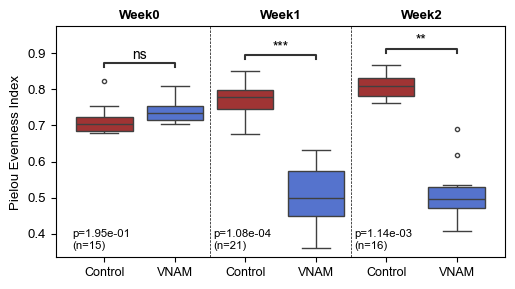

In [12]:
## pielou_e

# 1) Week 붙여서 합치기
alpha_all = pd.concat([
    w0_pielou.assign(Week="Week0"),
    w1_pielou.assign(Week="Week1"),
    w2_pielou.assign(Week="Week2"),
], ignore_index=True)

# 2) 6개 그룹 라벨 만들기: w0_con, w0_vnam, ...
alpha_all["Group6"] = alpha_all["Week"] + "_" + alpha_all["Group"]#.str.lower()

order = ["Week0_Control", "Week0_VNAM", "Week1_Control", "Week1_VNAM", "Week2_Control", "Week2_VNAM"]
# (원하면 con으로 줄이기)
#alpha_all["Group6"] = alpha_all["Group6"].replace({"w0_control":"w0_con","w1_control":"w1_con","w2_control":"w2_con"})
#order = ["w0_con","w0_vnam","w1_con","w1_vnam","w2_con","w2_vnam"]

# 3) plot
palette = ["firebrick", "royalblue"] * 3

fig, ax = plt.subplots(figsize=(5.8, 3))
sns.boxplot(data=alpha_all, x="Group6", y="pielou_evenness",
            order=order, palette=palette, fliersize=3, ax=ax)

# 4) 통계(각 Week에서 Control vs VNAM 3개 비교)
pairs = [("Week0_Control","Week0_VNAM"), ("Week1_Control","Week1_VNAM"), ("Week2_Control","Week2_VNAM")]
annot = Annotator(ax, pairs, data=alpha_all, x="Group6", y="pielou_evenness", order=order)
annot.configure(test="Kruskal", text_format="star", loc="inside")
annot.apply_test()
annot.annotate()

weeks = ["Week0", "Week1", "Week2"]
wk_info = {}  # {"Week0": (n_con, n_vnam, p), ...}

for wk in weeks:
    sub = alpha_all[alpha_all["Week"] == wk]
    con = sub.loc[sub["Group"] == "Control", "pielou_evenness"].dropna()
    vnam = sub.loc[sub["Group"] == "VNAM", "pielou_evenness"].dropna()
    stat, p = kruskal(con, vnam)
    wk_info[wk] = (len(con), len(vnam), p)

# 5) 2개 단위로 구분선(Seaborn 범주 위치는 0~5라서 경계는 1.5, 3.5)
ax.axvline(1.5, ymin=0, ymax=1, ls="--", lw=0.5, c="black")
ax.axvline(3.5, ymin=0, ymax=1, ls="--", lw=0.5, c="black")
# 사용자가 쓰던 절대 y범위로 자르고 싶으면:
# ax.vlines([1.5, 3.5], ymin=-5, ymax=35, linestyles="--", linewidth=0.5, colors="black")

trans = ax.get_xaxis_transform()  # x는 data좌표(0~5), y는 axes비율(0~1)

# 각 구역 center(x)와 left(x)
centers = {"Week0": 0.5, "Week1": 2.5, "Week2": 4.5}
lefts   = {"Week0": -0.45, "Week1": 1.55, "Week2": 3.55}

for wk in weeks:
    n_con, n_vnam, p = wk_info[wk]

    # 구역 위 제목
    ax.text(
        centers[wk], 1.02, wk,
        transform=trans, ha="center", va="bottom",
        fontsize=9.5, fontweight="bold", clip_on=False
    )

    # 구역 왼쪽 아래 n/p (원하면 n_con/n_vnam 형태로)
    ax.text(
        lefts[wk], 0.03,
        f"p={p:.2e}\n(n={n_con+n_vnam})",
        transform=trans, ha="left", va="bottom",
        fontsize=8.2
    )

ax.set_ylabel("Pielou Evenness Index", fontsize=9.5)
ax.set_xlabel("")
#ax.tick_params(axis="x", labelsize=9, rotation=45)
ax.tick_params(axis="y", labelsize=9.5)

new_labels = ["Control", "VNAM"] * 3
ax.set_xticklabels(new_labels, fontsize=9, rotation=0)

#ax.set_ylim(-100, )

#plt.savefig("pielou_weeks_merged.tiff", dpi=300, bbox_inches="tight")